In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("Libraries successfully loaded.")

Libraries successfully loaded.


In [2]:
import os
print("folder:")
print(os.getcwd())

folder:
C:\Users\ZEYNEP\house_price_prediction


In [3]:
df = pd.read_csv('data/kc_house_data.csv')

print("Dataset successfully loaded.")
print(f"\nSize of the dataset: {df.shape[0]} row, {df.shape[1]} column")

Dataset successfully loaded.

Size of the dataset: 21613 row, 21 column


In [4]:
print("First 5 rows.")
df.head()

First 5 rows.


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
print("Dataset information:")
print(df.info())
print("Row names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")
   

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 

In [6]:
print("Statistical summary:")
df.describe()

Statistical summary:


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [7]:
print("Missing value analysis:")
missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("There are no missing values")
else:
    print(missing_values[missing_values > 0])

Missing value analysis:
There are no missing values


In [8]:
print("Price Analysis (Target Variable):")
print(f"Average Price: ${df['price'].mean():,.2f}")
print(f"Median Price: ${df['price'].median():,.2f}")
print(f"Minimum Price: ${df['price'].min():,.2f}")
print(f"Maximum Price: ${df['price'].max():,.2f}")
print(f"Standard Deviation: ${df['price'].std():,.2f}")
print(f"\n1st quartile (Q1): ${df['price'].quantile(0.25):,.2f}")
print(f"\n3rd quartile (Q3): ${df['price'].quantile(0.75):,.2f}")


Price Analysis (Target Variable):
Average Price: $540,088.14
Median Price: $450,000.00
Minimum Price: $75,000.00
Maximum Price: $7,700,000.00
Standard Deviation: $367,127.20

1st quartile (Q1): $321,950.00

3rd quartile (Q3): $645,000.00


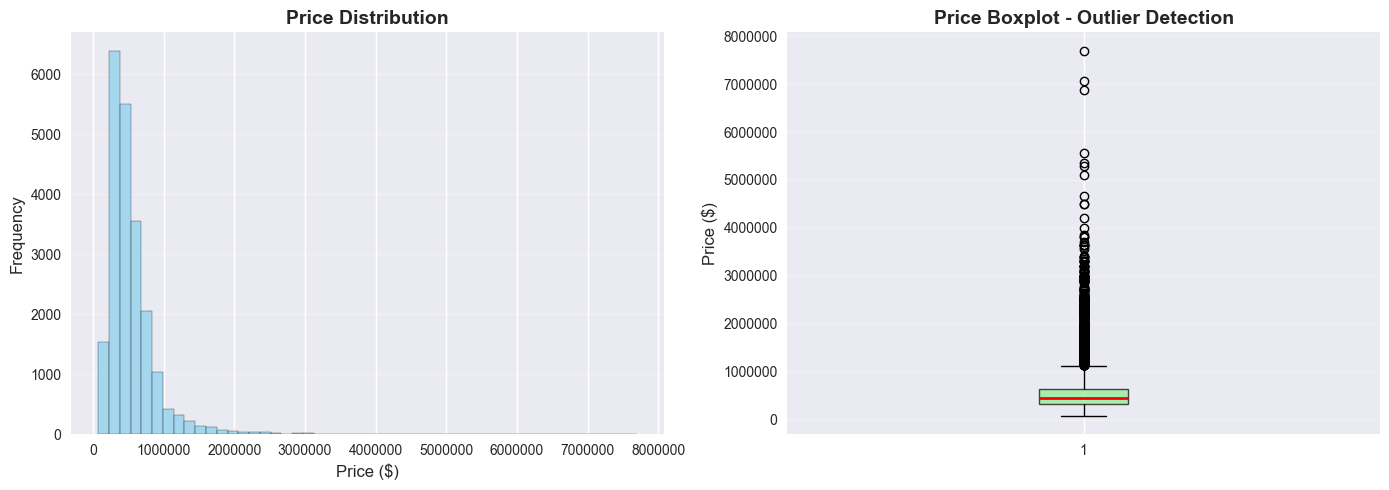

Points above the boxplot indicate outliers.


In [9]:
fig, axes =plt.subplots(1, 2, figsize = (14,5))

axes[0].hist(df['price'], bins = 50, edgecolor = 'black', alpha = 0.7, color = 'skyblue')
axes[0].set_xlabel('Price ($)', fontsize = 12)
axes[0].set_ylabel('Frequency', fontsize = 12)
axes[0].set_title('Price Distribution', fontsize = 14, fontweight = 'bold')
axes[0].ticklabel_format(style = 'plain', axis = 'x')
axes[0].grid(axis = 'y', alpha = 0.3)

bp = axes[1].boxplot(df['price'], vert = True, patch_artist = True, boxprops = dict(facecolor = 'lightgreen', alpha = 0.7), medianprops = dict(color = 'red', linewidth = 2))
axes[1].set_ylabel('Price ($)', fontsize = 12)
axes[1].set_title('Price Boxplot - Outlier Detection', fontsize = 14, fontweight = 'bold')
axes[1].ticklabel_format(style = 'plain', axis = 'y')
axes[1].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

print("Points above the boxplot indicate outliers.")

In [10]:
# OUTLIER ANALYSIS (IQR METHOD)

print("OUTLIER ANALYSIS")
print("="*80)

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_threshold = Q1 - 1.5 * IQR
upper_threshold = Q3 + 1.5 * IQR

print(f"\nPrice Statistics:")
print(f"  Q1 (25th percentile): ${Q1:,.2f}")
print(f"  Q3 (75th percentile): ${Q3:,.2f}")
print(f"  IQR: ${IQR:,.2f}")

print(f"\nOutlier Thresholds (IQR Method):")
print(f"  Lower threshold (Q1 - 1.5*IQR): ${lower_threshold:,.2f}")
print(f"  Upper threshold (Q3 + 1.5*IQR): ${upper_threshold:,.2f}")

#Count outliers
lower_outliers = df[df['price'] < lower_threshold]
upper_outliers = df[df['price'] > upper_threshold]
total_outliers = len(lower_outliers) + len(upper_outliers)

print(f"\nOutlier Count:")
print(f"  Lower outliers (too cheap): {len(lower_outliers)} ({len(lower_outliers)/len(df)*100:.2f}%)")
if len(lower_outliers) > 0:
    print(f"    Price range: ${lower_outliers['price'].min():,.2f} - ${lower_outliers['price'].max():,.2f}")

print(f"  Upper outliers (too expensive): {len(upper_outliers)} ({len(upper_outliers)/len(df)*100:.2f}%)")
if len(upper_outliers) > 0:
    print(f"    Price range: ${upper_outliers['price'].min():,.2f} - ${upper_outliers['price'].max():,.2f}")

print(f"  TOTAL outliers: {total_outliers} ({total_outliers/len(df)*100:.2f}%)")

print("\n" + "-"*80)
print("NOTE: For house price prediction, we focus on UPPER outliers")
print("(expensive houses) as lower outliers are rare in this dataset.")
print("-"*80)

OUTLIER ANALYSIS

Price Statistics:
  Q1 (25th percentile): $321,950.00
  Q3 (75th percentile): $645,000.00
  IQR: $323,050.00

Outlier Thresholds (IQR Method):
  Lower threshold (Q1 - 1.5*IQR): $-162,625.00
  Upper threshold (Q3 + 1.5*IQR): $1,129,575.00

Outlier Count:
  Lower outliers (too cheap): 0 (0.00%)
  Upper outliers (too expensive): 1146 (5.30%)
    Price range: $1,130,000.00 - $7,700,000.00
  TOTAL outliers: 1146 (5.30%)

--------------------------------------------------------------------------------
NOTE: For house price prediction, we focus on UPPER outliers
(expensive houses) as lower outliers are rare in this dataset.
--------------------------------------------------------------------------------


In [11]:
print("Numerical Features Analysis:")

numerical_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15']

df[numerical_cols].describe()

Numerical Features Analysis:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,1788.390691,291.509045,1971.005136,84.402258,1986.552492,12768.455652
std,0.930062,0.770163,918.440897,4.142051e+04,0.539989,828.090978,442.575043,29.373411,401.679240,685.391304,27304.179631
min,0.000000,0.000000,290.000000,5.200000e+02,1.000000,290.000000,0.000000,1900.000000,0.000000,399.000000,651.000000
25%,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,1190.000000,0.000000,1951.000000,0.000000,1490.000000,5100.000000
50%,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,1560.000000,0.000000,1975.000000,0.000000,1840.000000,7620.000000
75%,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,2210.000000,560.000000,1997.000000,0.000000,2360.000000,10083.000000
max,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,9410.000000,4820.000000,2015.000000,2015.000000,6210.000000,871200.000000


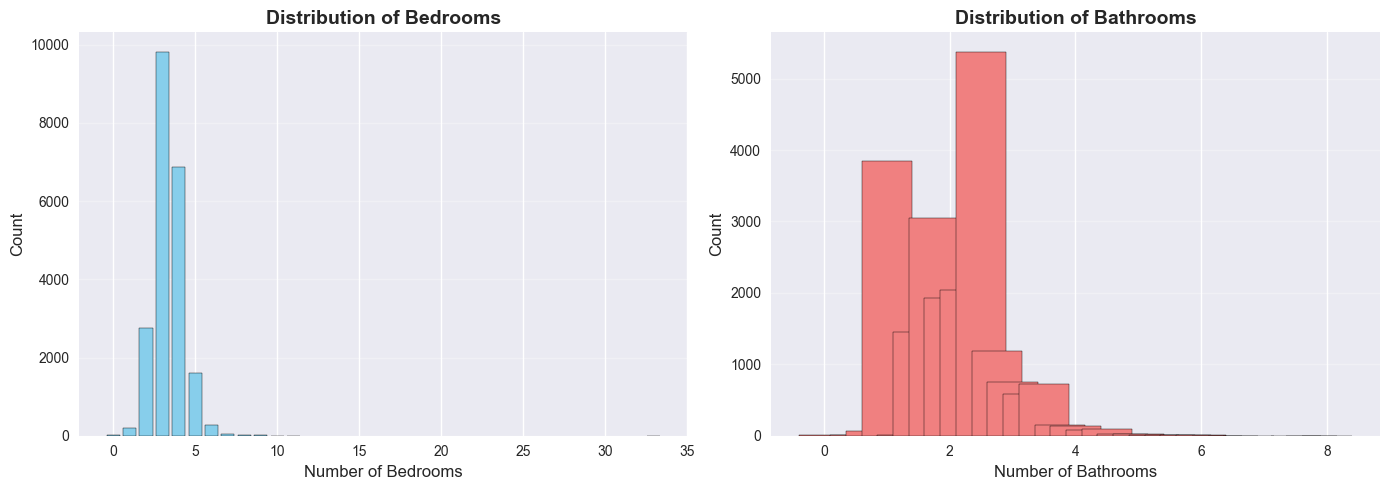


ANOMALY DETECTION REPORT

  Bedroom Anomaly Detection:
--------------------------------------------------------------------------------
Houses with 0 bedrooms: 13
Houses with >10 bedrooms: 2

Houses with > 10 bedrooms details:
       bedrooms  bathrooms  sqft_living     price
8757         11       3.00         3000  520000.0
15870        33       1.75         1620  640000.0

  Bathroom Anomaly Detection:
--------------------------------------------------------------------------------
Houses with 0 bathrooms: 10

 Houses with 0 bathrooms (DATA ERROR):
       bedrooms  bathrooms  sqft_living      price
875           0        0.0         3064  1095000.0
1149          1        0.0          670    75000.0
3119          0        0.0         1470   380000.0
5832          1        0.0          600   280000.0
6994          0        0.0         4810  1295650.0
9773          0        0.0         2460   355000.0
9854          0        0.0         1470   235000.0
10481         1        0.0        

In [12]:
fig, axes = plt.subplots(1, 2, figsize = (14,5))

bedroom_counts = df['bedrooms'].value_counts().sort_index()
axes[0].bar(bedroom_counts.index, bedroom_counts.values, color = 'skyblue', edgecolor = 'black')
axes[0].set_title('Distribution of Bedrooms', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Number of Bedrooms', fontsize = 12)
axes[0].set_ylabel('Count', fontsize = 12)
axes[0].grid(axis = 'y', alpha = 0.3)

bathroom_counts = df['bathrooms'].value_counts().sort_index()
axes[1].bar(bathroom_counts.index, bathroom_counts.values, color = 'lightcoral', edgecolor = 'black')
axes[1].set_title('Distribution of Bathrooms', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Number of Bathrooms', fontsize = 12)
axes[1].set_ylabel('Count', fontsize = 12)
axes[1].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANOMALY DETECTION REPORT")
print("="*80)

print("\n  Bedroom Anomaly Detection:")
print("-"*80)
print(f"Houses with 0 bedrooms: {(df['bedrooms'] == 0).sum()}")
print(f"Houses with >10 bedrooms: {(df['bedrooms'] > 10).sum()}")
print(f"\nHouses with > 10 bedrooms details:")
high_bed = df[df['bedrooms'] > 10]
if len(high_bed) > 0:
    print(high_bed[['bedrooms', 'bathrooms', 'sqft_living', 'price']])

if (df['bedrooms'] > 10).sum() > 10:
    print(f"\nHouses with >10 bedrooms details:")
    print(df[df['bedrooms'] > 0][['bedrooms', 'bathrooms', 'sqft_living', 'price']])
    
print("\n  Bathroom Anomaly Detection:")
print("-"*80)

zero_bath_count = (df['bathrooms'] == 0.0).sum()
print(f"Houses with 0 bathrooms: {zero_bath_count}")

if zero_bath_count > 0:
    print(f"\n Houses with 0 bathrooms (DATA ERROR):")
    print(df[df['bathrooms'] == 0.0][['bedrooms', 'bathrooms', 'sqft_living', 'price']])
else:
    print("No houses with 0 bathrooms.")



Correlation Analysis With Price


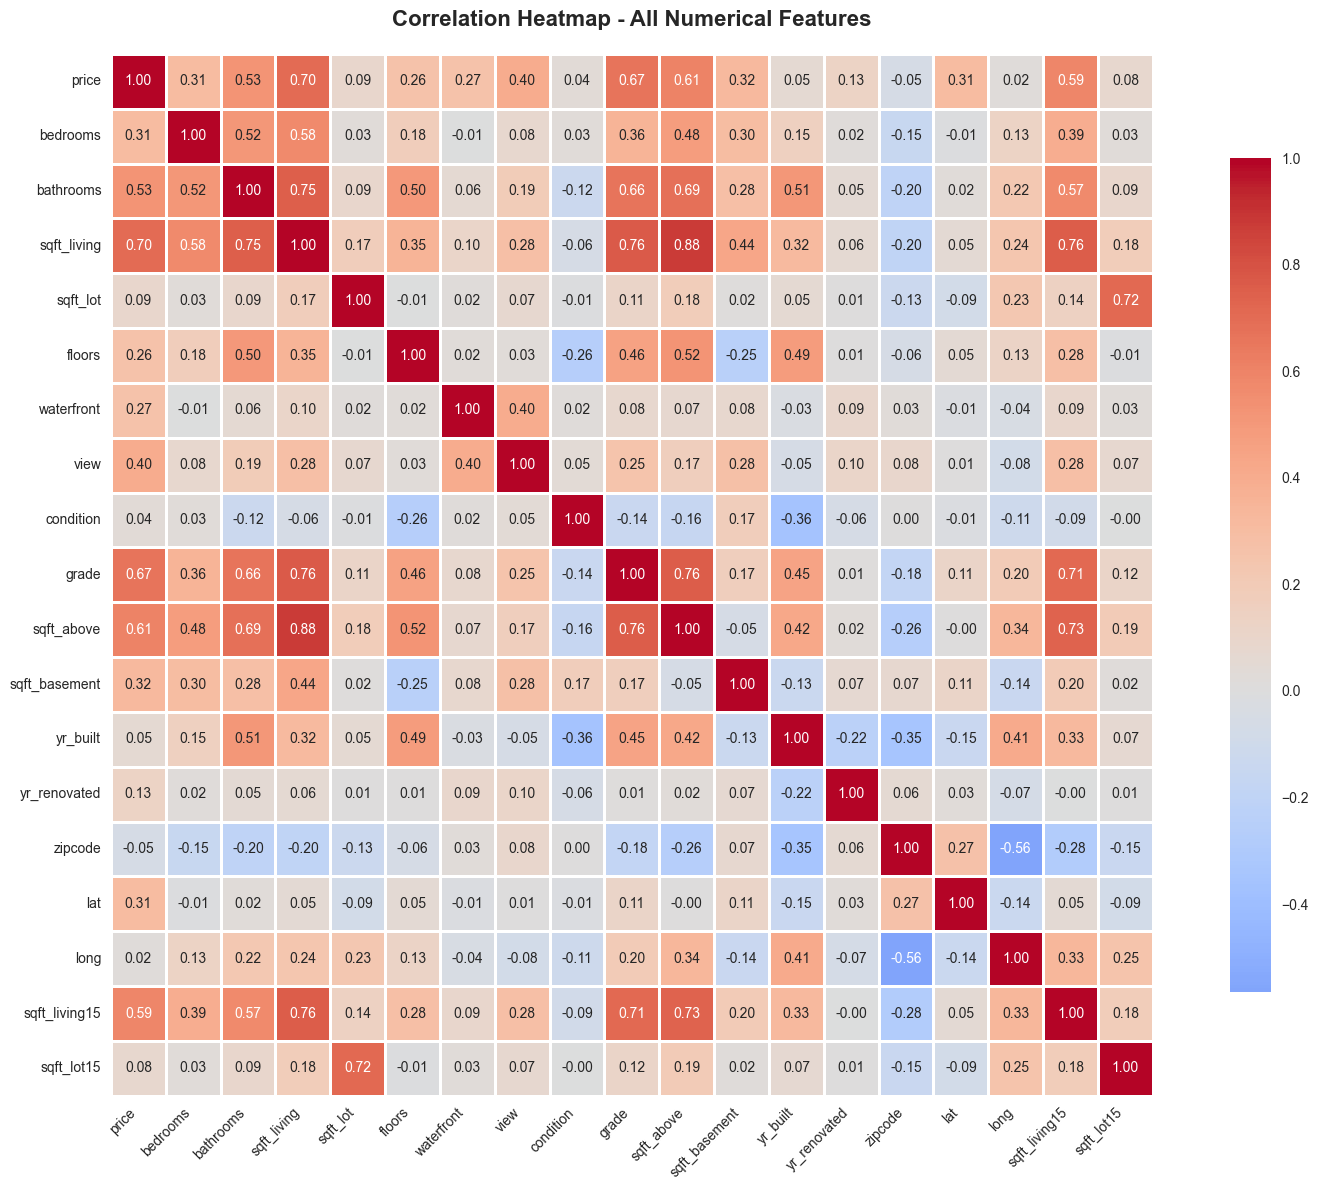


Top 10 Features Correlated With Price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
Name: price, dtype: float64
Interpretation:
Positive correlation (0.7 - 1): Strong positive relationship
Moderate correlation (0.3 - 0.7): Moderate relationship
Weak correlation (0.0 - 0.3): Weak relationship
Negative correlation: Inverse relationship


In [13]:
print("Correlation Analysis With Price")

numerical_features = df.select_dtypes(include = [np.number]).columns.tolist()

if 'id' in numerical_features:
    numerical_features.remove('id')

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize = (16, 12))
sns.heatmap(correlation_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0, square = True, linewidths = 1, cbar_kws = {"shrink": 0.8})
plt.title('Correlation Heatmap - All Numerical Features', fontsize = 16, fontweight = 'bold', pad = 20)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

print("\nTop 10 Features Correlated With Price:")

price_corr = correlation_matrix['price'].sort_values(ascending = False)
print(price_corr.head(11))

print("Interpretation:")

print("Positive correlation (0.7 - 1): Strong positive relationship")
print("Moderate correlation (0.3 - 0.7): Moderate relationship")
print("Weak correlation (0.0 - 0.3): Weak relationship")
print("Negative correlation: Inverse relationship")

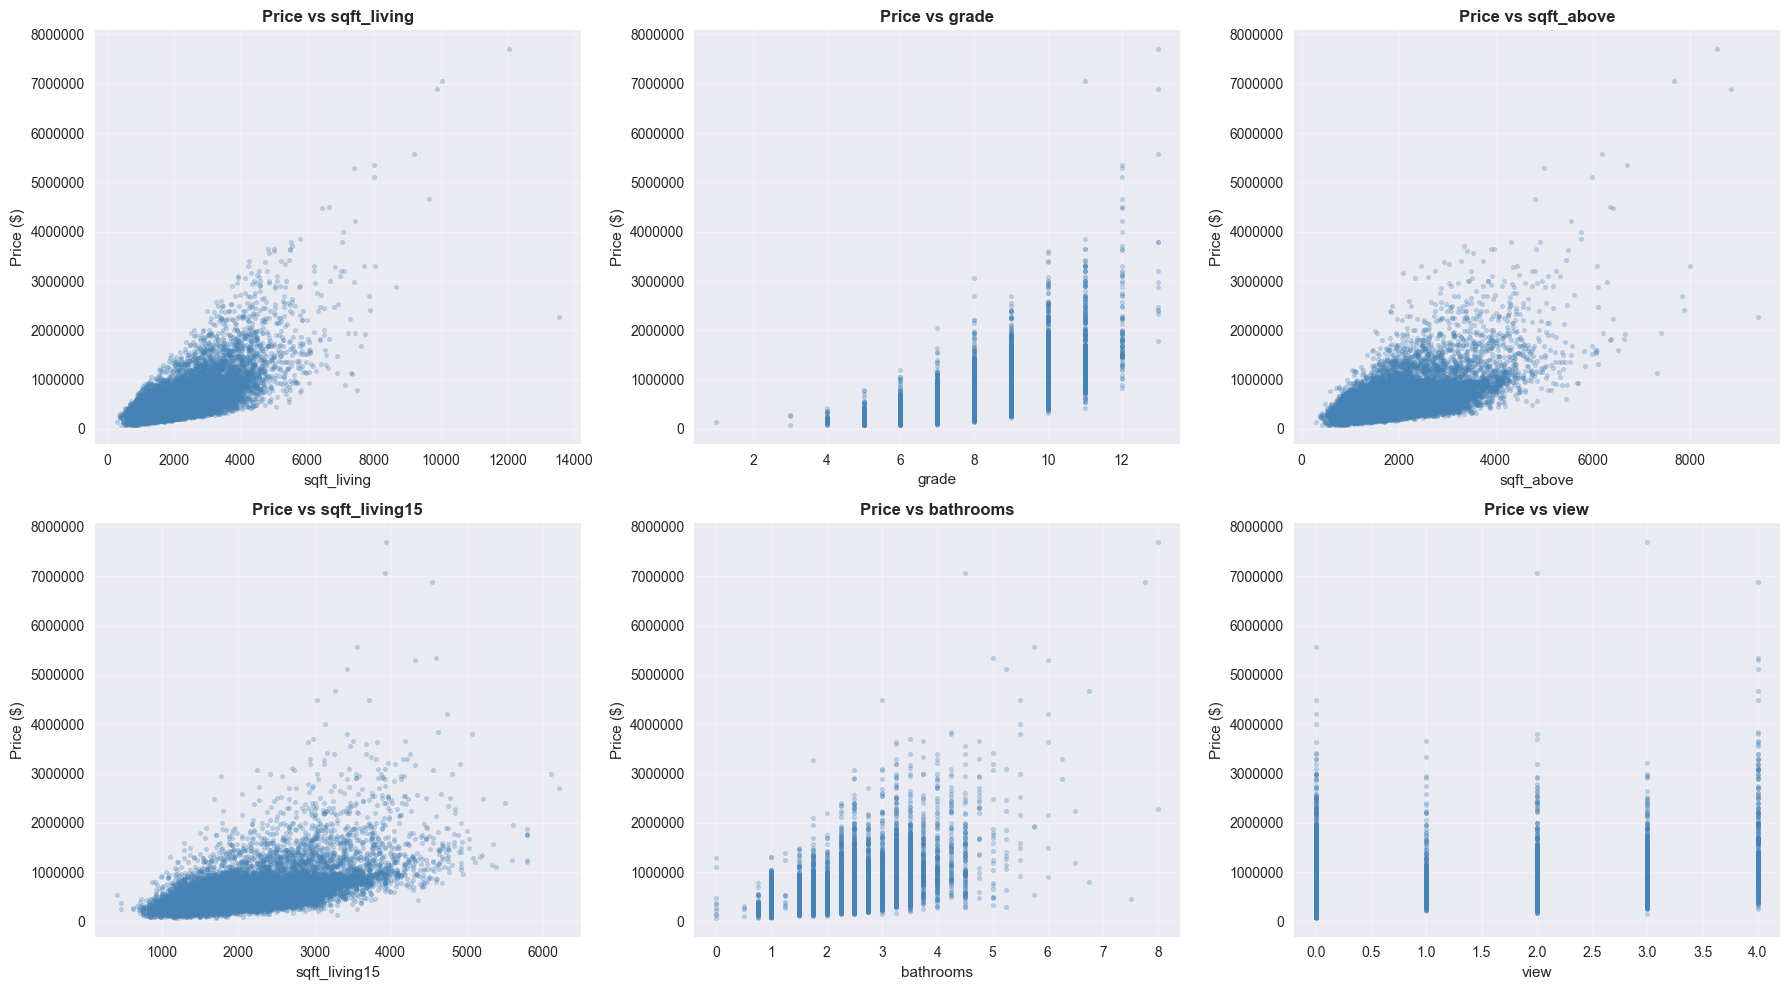


Observations:
-Linear relationships indicate features suitable for regression
-Scattered patterns may be need transformation of polynomial features


In [14]:
fig, axes = plt.subplots(2, 3, figsize = (18,10))
axes = axes.ravel()

top_features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view']

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['price'], alpha = 0.3, s = 10, color = 'steelblue')
    axes[idx].set_xlabel(feature, fontsize = 11)
    axes[idx].set_ylabel('Price ($)', fontsize = 11)
    axes[idx].set_title(f'Price vs {feature}', fontsize = 12, fontweight = 'bold')
    axes[idx].ticklabel_format(style = 'plain', axis = 'y')
    axes[idx].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("-Linear relationships indicate features suitable for regression")
print("-Scattered patterns may be need transformation of polynomial features")

CATEGORICAL FEATURES ANALYSIS

WATERFRONT - Value Counts
waterfront
0    21450
1      163
Name: count, dtype: int64

VIEW - Value Counts
view
0    19489
1      332
2      963
3      510
4      319
Name: count, dtype: int64

CONDITION - Value Counts
condition
1       30
2      172
3    14031
4     5679
5     1701
Name: count, dtype: int64

GRADE - Value Counts
grade
1        1
3        3
4       29
5      242
6     2038
7     8981
8     6068
9     2615
10    1134
11     399
12      90
13      13
Name: count, dtype: int64


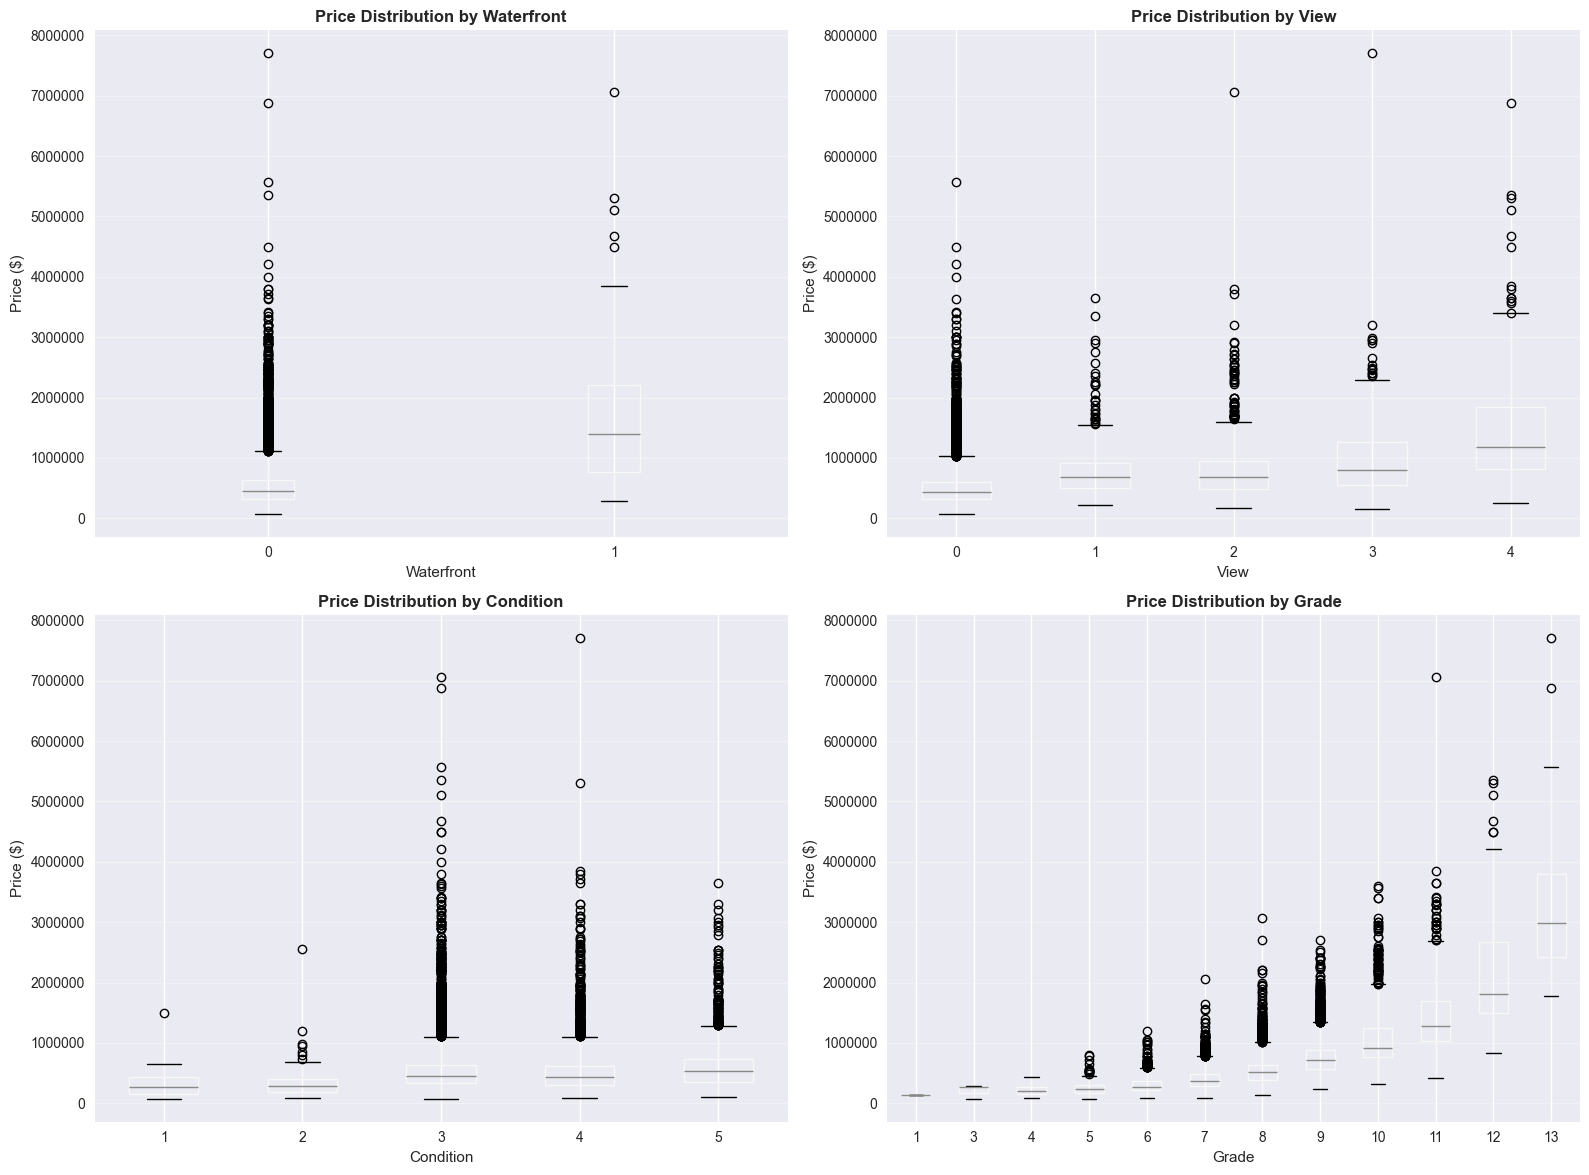


 KEY INSIGHTS:
--------------------------------------------------------------------------------
-Waterfront: Only 0.75% (163 houses) but 3x price impact → Very Strong
-View: 0-4 scale, clear progression, View=4 doubles price → Moderate
-Condition: 1-5 scale, but weak price variation → Weak predictor
-Grade: 1-13 scale, strong linear relationship, 15x price range → Strongest categorical
-Grade 7-8 most common (15,049 houses = 70%)
-Grade 11-13 ultra-luxury (502 houses, median >$1.5M)


In [15]:
print("CATEGORICAL FEATURES ANALYSIS")
print("="*80)

categorical_cols = ['waterfront', 'view', 'condition', 'grade']

for col in categorical_cols:
    print(f"\n{col.upper()} - Value Counts")
    print(df[col].value_counts().sort_index())

fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):

    df.boxplot(column='price', by=col, ax=axes[idx])
    axes[idx].set_title(f'Price Distribution by {col.capitalize()}', fontsize = 12, fontweight = 'bold')
    axes[idx].set_xlabel(col.capitalize(), fontsize = 11)
    axes[idx].set_ylabel('Price ($)', fontsize = 11)
    axes[idx].ticklabel_format(style = 'plain', axis = 'y')
    axes[idx].grid(axis='y', alpha = 0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\n KEY INSIGHTS:")
print("-"*80)
print("-Waterfront: Only 0.75% (163 houses) but 3x price impact → Very Strong")
print("-View: 0-4 scale, clear progression, View=4 doubles price → Moderate")
print("-Condition: 1-5 scale, but weak price variation → Weak predictor")
print("-Grade: 1-13 scale, strong linear relationship, 15x price range → Strongest categorical")
print("-Grade 7-8 most common (15,049 houses = 70%)")
print("-Grade 11-13 ultra-luxury (502 houses, median >$1.5M)")

GEOGRAPHICAL ANALYSIS

LATITUDE Statistics:
Min: 47.1559
Max: 47.7776
Mean: 47.5601
LONGITUDE Statistics:
Min: -122.5190
Mean: -122.2139
Max: -121.3150


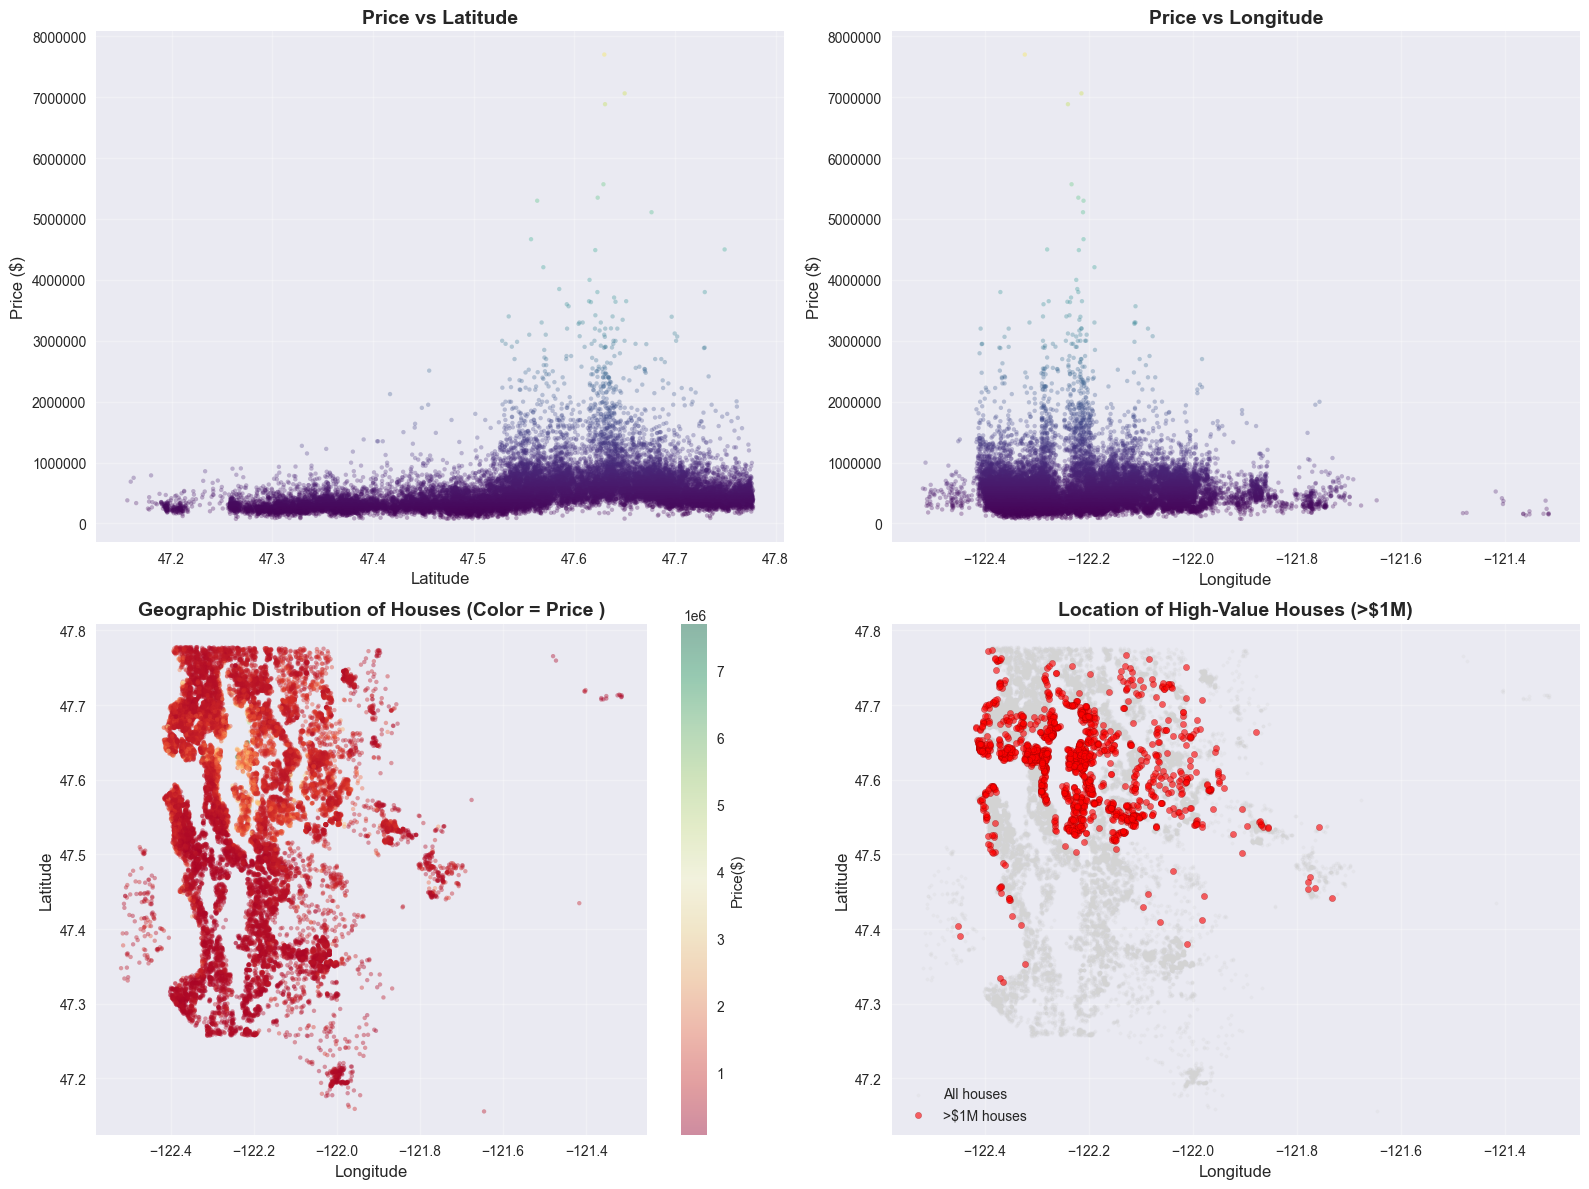


PRICE ANALYSIS BY LOCATION ZONES:
--------------------------------------------------------------------------------

NORTH (lat > 47.5718):
 Count: 10802
 Mean Price: $661,347.23
 Median Price: $560,000.00

SOUTH (lat <= 47.5718):
 Count: 10811
 Mean Price: $418,930.00
 Median Price: $340,000.00

EAST (long > -122.2300):
 Count: 10785
 Mean Price: $563,722.08
 Median Price: $475,000.00

WEST (long <= -122.2300):
 Count: 10828
 Mean Price: $516,548.05
 Median Price: $430,000.00

 KEY INSIGHTS:
--------------------------------------------------------------------------------
-Latitude shows north-south variation in prices
-Longitude shows east-west variation in prices
-Geographic clustering of high-value properties indicates premium neighborhoods
-Waterfront properties likely concentrated in specific areas


In [16]:
print("GEOGRAPHICAL ANALYSIS")
print("="*80)

print("\nLATITUDE Statistics:")
print(f"Min: {df['lat'].min():.4f}")
print(f"Max: {df['lat'].max():.4f}")
print(f"Mean: {df['lat'].mean():.4f}")

print("LONGITUDE Statistics:")
print(f"Min: {df['long'].min():.4f}")
print(f"Mean: {df['long'].mean():.4f}")
print(f"Max: {df['long'].max():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(df['lat'], df['price'], alpha=0.3, s=10, c=df['price'], cmap='viridis', edgecolors='none')
axes[0, 0].set_xlabel('Latitude', fontsize=12)
axes[0, 0].set_ylabel('Price ($)', fontsize=12)
axes[0, 0].set_title('Price vs Latitude', fontsize=14, fontweight='bold')
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(df['long'], df['price'], alpha=0.3, s=10, c=df['price'], cmap='viridis', edgecolors='none')
axes[0, 1].set_xlabel('Longitude', fontsize=12)
axes[0, 1].set_ylabel('Price ($)', fontsize=12)
axes[0, 1].set_title('Price vs Longitude', fontsize=14, fontweight='bold')
axes[0, 1].ticklabel_format(style='plain', axis='y')
axes[0, 1].grid(alpha=0.3)

scatter = axes[1, 0].scatter(df['long'], df['lat'], alpha=0.4, s=10, c=df['price'], cmap='RdYlGn', edgecolors='none')
axes[1, 0].set_xlabel('Longitude', fontsize=12)
axes[1, 0].set_ylabel('Latitude', fontsize=12)
axes[1, 0].set_title('Geographic Distribution of Houses (Color = Price )', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Price($)', fontsize=11)

expensive_houses = df[df['price'] > 1000000]
axes[1, 1].scatter(df['long'], df['lat'], alpha=0.2, s=5, c='lightgray', label='All houses')
axes[1, 1].scatter(expensive_houses['long'], expensive_houses['lat'], alpha=0.6, s=20, c='red', edgecolors='darkred', label='>$1M houses')
axes[1, 1].set_xlabel('Longitude', fontsize=12)
axes[1, 1].set_ylabel('Latitude', fontsize=12)
axes[1, 1].set_title('Location of High-Value Houses (>$1M)', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='best', fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPRICE ANALYSIS BY LOCATION ZONES:")
print("-"*80)

median_lat = df['lat'].median()
north_prices = df[df['lat'] > median_lat]['price']
south_prices = df[df['lat'] <= median_lat]['price']

print(f"\nNORTH (lat > {median_lat:.4f}):")
print(f" Count: {len(north_prices)}")
print(f" Mean Price: ${north_prices.mean():,.2f}")
print(f" Median Price: ${north_prices.median():,.2f}")

print(f"\nSOUTH (lat <= {median_lat:.4f}):")
print(f" Count: {len(south_prices)}")
print(f" Mean Price: ${south_prices.mean():,.2f}")
print(f" Median Price: ${south_prices.median():,.2f}")

median_long = df['long'].median()
east_prices = df[df['long'] > median_long]['price']
west_prices = df[df['long'] <= median_long]['price']

print(f"\nEAST (long > {median_long:.4f}):")
print(f" Count: {len(east_prices)}")
print(f" Mean Price: ${east_prices.mean():,.2f}")
print(f" Median Price: ${east_prices.median():,.2f}")

print(f"\nWEST (long <= {median_long:.4f}):")
print(f" Count: {len(west_prices)}")
print(f" Mean Price: ${west_prices.mean():,.2f}")
print(f" Median Price: ${west_prices.median():,.2f}")

print("\n KEY INSIGHTS:")
print("-"*80)
print("-Latitude shows north-south variation in prices")
print("-Longitude shows east-west variation in prices")
print("-Geographic clustering of high-value properties indicates premium neighborhoods")
print("-Waterfront properties likely concentrated in specific areas")